### Evaluation for the models trained in trainings.py


In [1]:
import warnings
import logging


# Configure logger
logger = logging.getLogger()
logger.setLevel(logging.ERROR)


import gymnasium as gym
from stable_baselines3 import DQN
from sb3_contrib import RecurrentPPO

from register_envs import register_custom_envs
import utils

from random import seed

# For reproductibility
seed(1)

register_custom_envs()

# Suppress UserWarning and DeprecationWarning
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [5]:
# Constants

#model_folder = "checkpoints"
model_folder = "best_models"
n_episodes = 50 
print_example = False

In [7]:
results = {}

for version in ["v0","v1","v2"]:
    print("="*50)
    print(f"Evaluating best model for OpenTheChests-{version}:")
    print("="*50)
    env = gym.make(f"OpenTheChests-{version}")
    if version == "v0":
        model = DQN.load(f'{model_folder}/best_model_{version}')
    else:
        env = utils.FloatActionWrapper(env)
        model = RecurrentPPO.load(f'{model_folder}/best_model_{version}')
    
    stats = utils.evaluate_model(model, env, num_episodes=n_episodes) #to get stats
    if print_example:
        utils.evaluate_model(model,env,num_episodes=1,verbose=True) #to get example run
    print("Evaluation Results : ")
    for metric, value in stats.items():
        print(f"{metric} : {value}")
    
    results[version] = stats


Evaluating best model for OpenTheChests-v0:


Evaluating: 100%|██████████| 50/50 [00:00<00:00, 132.58it/s]


Evaluation Results : 
mean_reward : 3.0
std_reward : 0.0
min_reward : 3.0
max_reward : 3.0
mean_length : 3.3
std_length : 0.5744562646538028
success_rate : 1.0
Evaluating best model for OpenTheChests-v1:


Evaluating: 100%|██████████| 50/50 [00:02<00:00, 18.23it/s]


Evaluation Results : 
mean_reward : 0.8
std_reward : 0.565685424949238
min_reward : -1.0
max_reward : 1.0
mean_length : 13.36
std_length : 1.6463292501805342
success_rate : 0.88
Evaluating best model for OpenTheChests-v2:


Evaluating: 100%|██████████| 50/50 [00:12<00:00,  4.05it/s]

Evaluation Results : 
mean_reward : -38.56
std_reward : 9.349138997790119
min_reward : -58.0
max_reward : -24.0
mean_length : 56.94
std_length : 7.349585022298878
success_rate : 0.0


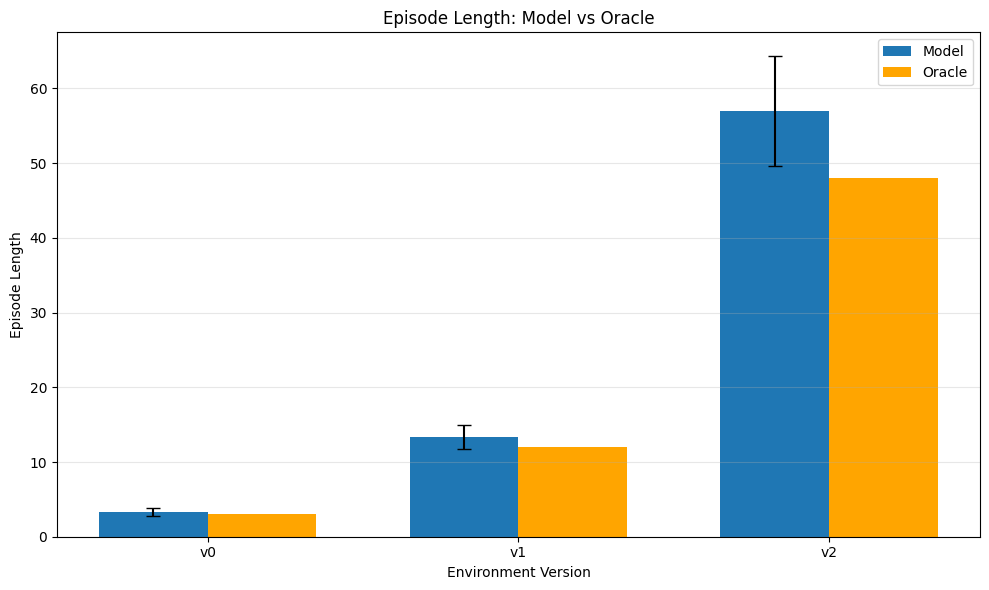

In [ ]:
# Barplot: Episode lengths vs Oracle
import matplotlib.pyplot as plt
import numpy as np

oracle_lengths = {"v0": 3, "v1": 12, "v2": 48}
versions = ["v0", "v1", "v2"]

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(versions))
width = 0.35

# Model performance
model_lengths = [results[v]["mean_length"] for v in versions]
model_stds = [results[v]["std_length"] for v in versions]
oracle_vals = [oracle_lengths[v] for v in versions]

bars1 = ax.bar(x - width/2, model_lengths, width, label="Model", yerr=model_stds, capsize=5)
bars2 = ax.bar(x + width/2, oracle_vals, width, label="Oracle", color='orange')

ax.set_xlabel("Environment Version")
ax.set_ylabel("Episode Length")
ax.set_title("Episode Length (shorter is better): Model vs Oracle")
ax.set_xticks(x)
ax.set_xticklabels(versions)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
